[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/espg/mortie/HEAD?labpath=examples%2Fmorton_coverage_example.ipynb)


# Morton Coverage Example

`mortie` covers a polygon (lat/lon vertices) with HEALPix cells via a top-down
hierarchical descent.

The compact, recommended output is a **Multi-Order Coverage (MOC)** —
`morton_coverage_moc` — with coarse cells in the interior and fine cells only
along the boundary (a plain `int64` array, since each morton index self-encodes
its order). A flat, single-order list is one call away: `morton_coverage(...)`,
or `moc_to_order(moc, order)` to densify a MOC.

**Key properties:**
- **Exact** — a cell is covered iff it intersects the closed polygon (a superset of the polygon)
- **Compact** — the MOC is typically far smaller than the flat cover
- **Scales with the boundary, not the area** — interior regions collapse to a few coarse cells

This notebook leads with the MOC, shows how to recover a flat cover, then
visualises coverage for synthetic and real-world polygons — including the full
Antarctic continent and a polygon with a hole.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import healpy as hp
from shapely.geometry import Polygon as ShapelyPolygon
import mortie
import time
from pathlib import Path

### Visualisation helpers

The cell below defines three helper functions:
- `morton_cell_geometries()` — converts morton indices to Shapely polygons for plotting (handles pole-touching cells via stereographic projection)
- `plot_polygon_boundary()` — draws polygon edges, splitting at antimeridian crossings
- `plot_coverage()` — combines both: runs `morton_coverage`, renders cells and boundary on a cartopy axis

In [2]:
def morton_cell_geometries(morton_indices, step=16):
    """Get shapely Polygon geometries for each morton cell in lon/lat coords."""
    nested, order = mortie.mort2healpix(morton_indices)
    nested = np.atleast_1d(nested)
    nside = 2**order

    geoms = []
    for pix in nested:
        xyz = hp.boundaries(nside, pix, step=step, nest=True)
        lons, lats = hp.vec2ang(xyz.T, lonlat=True)

        # Cell center longitude for normalization (handles 0/360 and antimeridian)
        center_lon, _ = hp.pix2ang(nside, pix, nest=True, lonlat=True)
        if center_lon > 180:
            center_lon -= 360

        # Detect pole-touching cells: any vertex with |lat| > 89.5°
        if np.any(np.abs(lats) > 89.5):
            # Use polar stereographic projection to avoid longitude wrapping
            pole_lat = -90.0 if np.mean(lats) < 0 else 90.0
            sign = -1.0 if pole_lat < 0 else 1.0
            lats_r = np.radians(lats)
            lons_r = np.radians(lons)
            # Stereographic projection centered on the pole
            k = 2.0 / (1.0 + sign * np.sin(lats_r))
            sx = k * np.cos(lats_r) * np.cos(lons_r)
            sy = k * np.cos(lats_r) * np.sin(lons_r)
            # Build polygon in projected space and densify
            poly_proj = ShapelyPolygon(zip(sx, sy))
            # Densify: interpolate along the projected boundary
            boundary = poly_proj.exterior
            n_pts = max(64, len(lons))
            distances = np.linspace(0, boundary.length, n_pts, endpoint=False)
            pts = [boundary.interpolate(d) for d in distances]
            sx_d = np.array([p.x for p in pts])
            sy_d = np.array([p.y for p in pts])
            # Inverse stereographic: back to lon/lat
            rho = np.sqrt(sx_d**2 + sy_d**2)
            c = 2.0 * np.arctan2(rho, 2.0)
            out_lats = np.degrees(np.arcsin(sign * np.cos(c)))
            out_lons = np.degrees(np.arctan2(sy_d, sx_d))
            # At the exact pole, atan2(0,0)=0 is wrong; use cell center instead
            out_lons[rho < 1e-10] = center_lon
            # Normalize longitudes relative to cell center for continuity
            out_lons = center_lon + ((out_lons - center_lon + 180) % 360 - 180)
            geoms.append(ShapelyPolygon(zip(out_lons, out_lats)))
        else:
            # Normalize longitudes relative to cell center (handles 0/360 seam
            # and antimeridian crossings without sequential unwrapping)
            lons = center_lon + ((lons - center_lon + 180) % 360 - 180)
            geoms.append(ShapelyPolygon(zip(lons, lats)))
    return geoms

def plot_polygon_boundary(lons, lats, ax, **kwargs):
    """Plot a polygon boundary handling antimeridian crossings.
    
    Splits the line at longitude jumps > 180° so cartopy doesn't
    draw straight lines across the map.
    """
    poly_lons = np.append(lons, lons[0])
    poly_lats = np.append(lats, lats[0])
    
    # Split at antimeridian crossings
    segments_lon = []
    segments_lat = []
    seg_lon = [poly_lons[0]]
    seg_lat = [poly_lats[0]]
    for i in range(1, len(poly_lons)):
        if abs(poly_lons[i] - poly_lons[i-1]) > 180:
            segments_lon.append(np.array(seg_lon))
            segments_lat.append(np.array(seg_lat))
            seg_lon = [poly_lons[i]]
            seg_lat = [poly_lats[i]]
        else:
            seg_lon.append(poly_lons[i])
            seg_lat.append(poly_lats[i])
    segments_lon.append(np.array(seg_lon))
    segments_lat.append(np.array(seg_lat))
    
    for slon, slat in zip(segments_lon, segments_lat):
        ax.plot(slon, slat, transform=ccrs.PlateCarree(), **kwargs)

def plot_coverage(lats, lons, order, ax, title=None):
    """Plot polygon boundary and morton coverage cell boundaries on a cartopy axis."""
    t0 = time.perf_counter()
    cells = mortie.morton_coverage(lats, lons, order=order)
    dt = (time.perf_counter() - t0) * 1000

    geoms = morton_cell_geometries(cells)
    ax.add_geometries(
        geoms, crs=ccrs.PlateCarree(),
        facecolor='lightblue', edgecolor='steelblue',
        linewidth=0.8, alpha=0.6, zorder=3,
    )

    plot_polygon_boundary(lons, lats, ax,
                          color='r', linewidth=2, zorder=4, label='Polygon')

    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
    ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)
    ax.legend(loc='lower left', fontsize=8)
    if title:
        ax.set_title(f'{title}\n{len(cells)} cells, {dt:.1f} ms')
    return cells

## Lead with the MOC output

`morton_coverage_moc` is the compact default. Below: a square's MOC (cells
**coloured by order** — dark = coarse interior, bright = fine boundary), and how
to recover a flat single-order cover from it.

In [ ]:
import matplotlib as mpl
from matplotlib.collections import PolyCollection

def draw_cells(ax, morton, max_order, by_order=True):
    "Plot cell footprints; densify edges (step) so coarse cells tile cleanly."
    verts, ords = [], []
    for m in morton:
        o = mortie.infer_order_from_morton(int(m)); ords.append(o)
        step = int(min(32, max(1, 2 ** (max_order - o))))
        c = np.asarray(mortie.mort2polygon(int(m), step=step))   # [lat, lon] rows
        verts.append(ax.projection.transform_points(ccrs.PlateCarree(), c[:, 1], c[:, 0])[:, :2])
    if by_order and ords:
        norm = mpl.colors.Normalize(min(ords), max(ords))
        ax.add_collection(PolyCollection(verts, facecolors=mpl.cm.viridis(norm(np.array(ords))), edgecolors="none"))
    else:
        ax.add_collection(PolyCollection(verts, facecolors="#4477aa", edgecolors="none"))
    pts = np.concatenate(verts)
    ax.set_xlim(pts[:, 0].min(), pts[:, 0].max()); ax.set_ylim(pts[:, 1].min(), pts[:, 1].max())

lats_sq = np.array([40.0, 40.0, 50.0, 50.0])
lons_sq = np.array([-125.0, -115.0, -115.0, -125.0])
order = 10

moc = mortie.morton_coverage_moc(lats_sq, lons_sq, order=order)   # compact, mixed-order (default)
flat = mortie.morton_coverage(lats_sq, lons_sq, order=order)       # flat, single-order

# A flat cover is one helper call away — and it is the SAME cover:
flat_from_moc = mortie.moc_to_order(moc, order)
assert set(int(x) for x in flat_from_moc) == set(int(x) for x in flat)
print(f"MOC {len(moc):,} cells  ->  moc_to_order -> flat {len(flat_from_moc):,} cells "
      f"(== morton_coverage {len(flat):,})")

proj = ccrs.Orthographic(-120, 45)
fig, axes = plt.subplots(1, 2, figsize=(11, 5), subplot_kw=dict(projection=proj))
draw_cells(axes[0], moc, order, by_order=True);   axes[0].set_title(f"MOC (default) \u2014 {len(moc):,} cells")
draw_cells(axes[1], flat, order, by_order=False);  axes[1].set_title(f"flat \u2014 {len(flat):,} cells")
plt.show()


## Synthetic Polygons (Orthographic)

Simple triangle and square at orders 4, 6, and 8. Observe how cell resolution
increases with order — order 4 has coarse cells, order 8 tightly traces the boundary.

/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor

/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


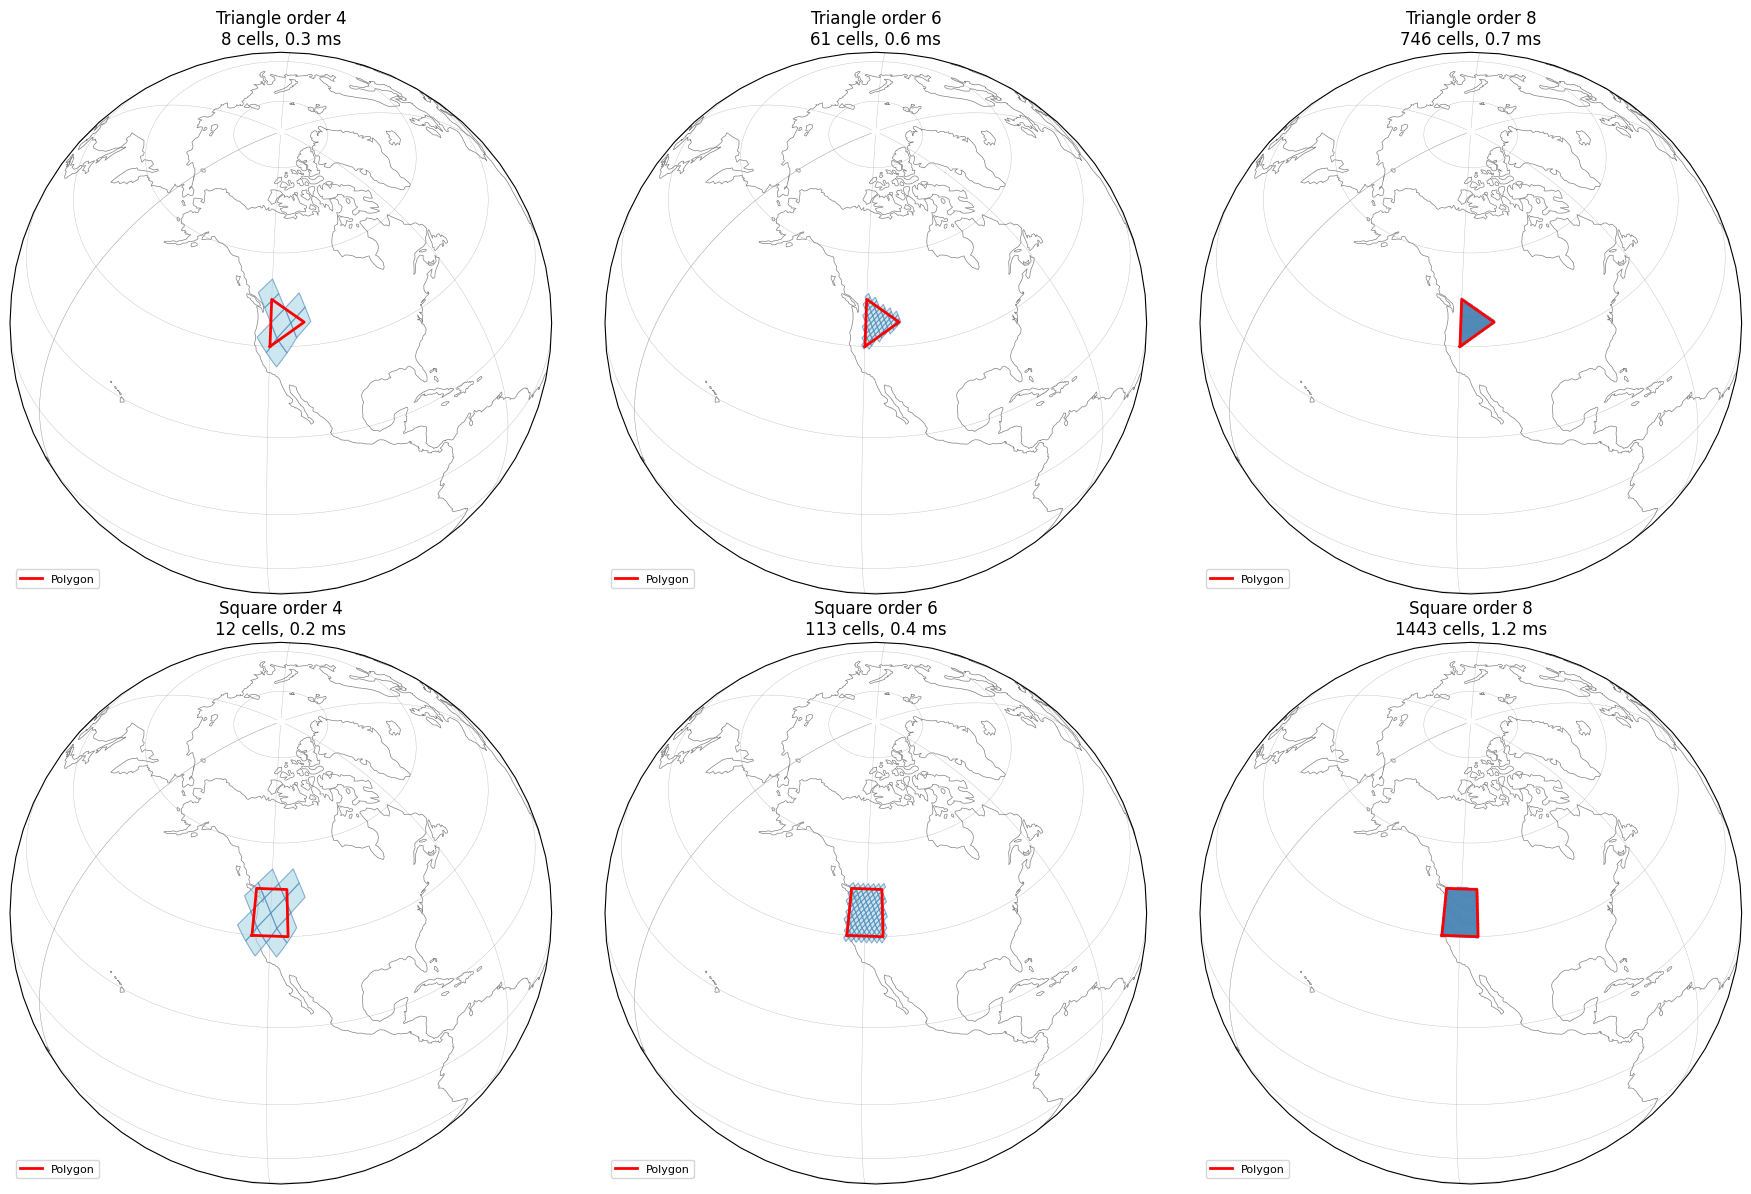

In [4]:
# Triangle
lats_t = np.array([40.0, 50.0, 45.0])
lons_t = np.array([-120.0, -120.0, -110.0])

# Square
lats_s = np.array([40.0, 40.0, 50.0, 50.0])
lons_s = np.array([-125.0, -115.0, -115.0, -125.0])

fig = plt.figure(figsize=(18, 12))
proj = ccrs.Orthographic(central_longitude=-117, central_latitude=45)

for row, (name, la, lo) in enumerate([('Triangle', lats_t, lons_t), ('Square', lats_s, lons_s)]):
    for col, order in enumerate([4, 6, 8]):
        ax = fig.add_subplot(2, 3, row*3 + col + 1, projection=proj)
        ax.set_global()
        plot_coverage(la, lo, order, ax, title=f'{name} order {order}')

plt.tight_layout()
plt.show()

## Circle (100 vertices, southern hemisphere) — South Polar

A challenging case: a circular polygon near the south pole (lat -75, radius 5 deg).
Longitudes converge at the pole, so boundary cell geometries are tricky to render.
Pole-touching cells use stereographic projection to avoid the "bowtie" artefact.

/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


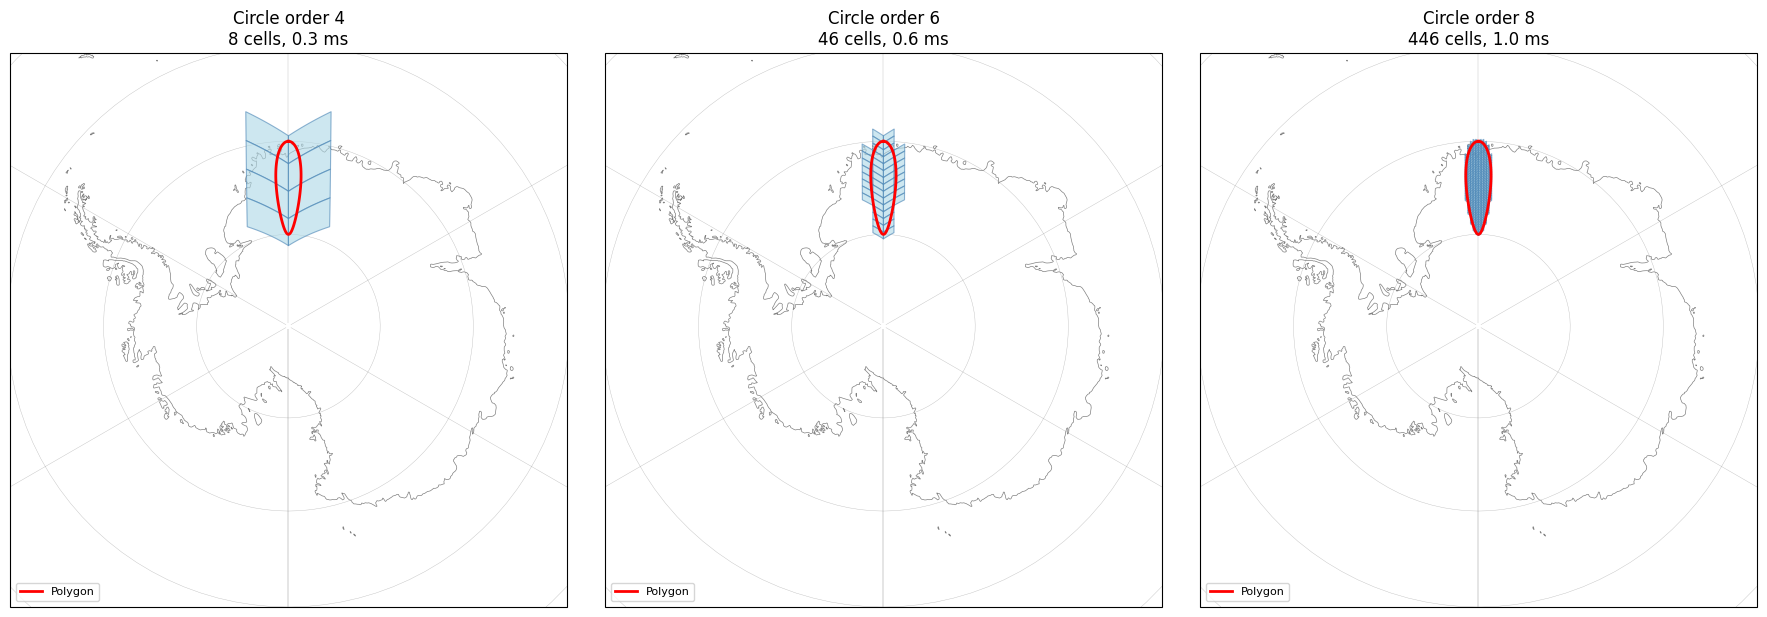

In [5]:
n = 100
angles = np.linspace(0, 2*np.pi, n, endpoint=False)
lats_c = -75.0 + 5.0 * np.cos(angles)
lons_c = 0.0 + 5.0 * np.sin(angles)

fig = plt.figure(figsize=(18, 6))
proj = ccrs.SouthPolarStereo()

for i, order in enumerate([4, 6, 8]):
    ax = fig.add_subplot(1, 3, i+1, projection=proj)
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    plot_coverage(lats_c, lons_c, order, ax, title=f'Circle order {order}')

plt.tight_layout()
plt.show()

## Antarctic Drainage Basins — South Polar Stereographic

Three representative basins from the Antarctic grounded drainage system dataset:
- **Basin 24** (smallest, ~21k vertices) — compact region, tests small-polygon handling
- **Basin 1** (largest, ~81k vertices) — wide basin, tests a large interior
- **Basin 2** (pole + antimeridian crossing, ~43k vertices) — the hardest case, stresses both longitude wrapping and polar geometry

Polygons are simplified to ~500 vertices for faster plotting (coverage is computed on the simplified version).

/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


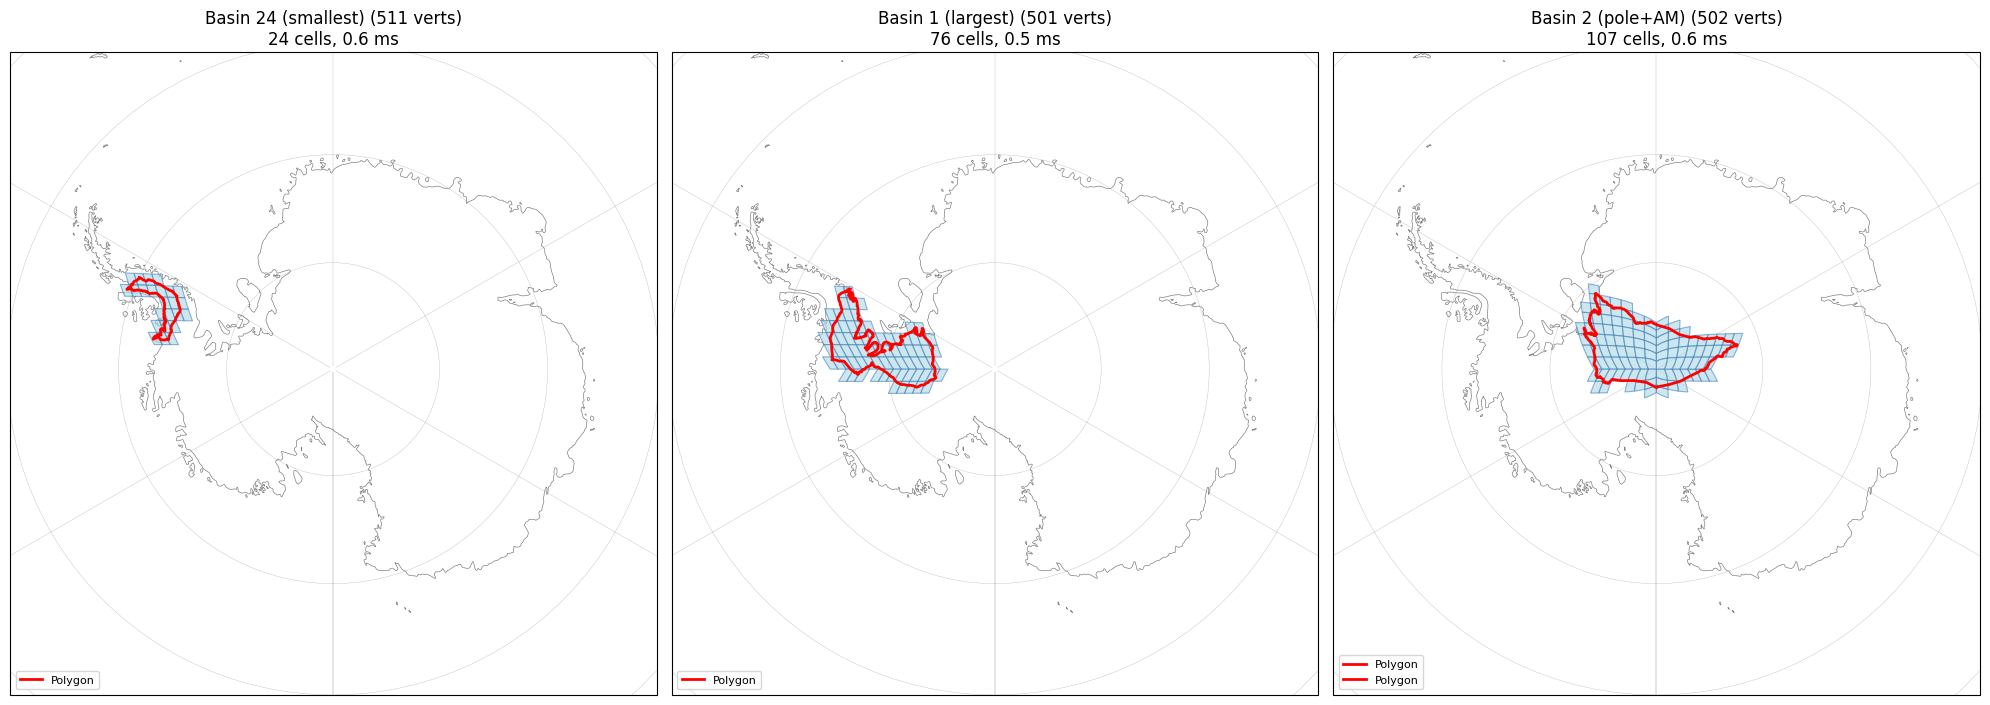

In [6]:
data_file = Path('../mortie/tests/Ant_Grounded_DrainageSystem_Polygons.txt')
assert data_file.exists(), 'Antarctic polygon data not found'
data = np.loadtxt(data_file)

fig = plt.figure(figsize=(20, 7))
proj = ccrs.SouthPolarStereo()

for idx, (bid, name) in enumerate([
    (24, 'Basin 24 (smallest)'),
    (1, 'Basin 1 (largest)'),
    (2, 'Basin 2 (pole+AM)')
]):
    mask = data[:, 2] == bid
    lats = data[mask, 0]
    lons = data[mask, 1]

    # Simplify for plotting
    step = max(1, len(lats) // 500)
    la_s, lo_s = lats[::step], lons[::step]

    ax = fig.add_subplot(1, 3, idx+1, projection=proj)
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    plot_coverage(la_s, lo_s, order=6, ax=ax, title=f'{name} ({len(la_s)} verts)')

plt.tight_layout()
plt.show()

## Full Antarctica — all 27 drainage basins (multipart)

The whole continent as a **multipart** polygon (one ring per basin; all rings
covered by one even-odd descent), shown across methods: flat, the **MOC**
(default), and the adaptive `tolerance` / `max_cells` variants (cells coloured by
order). The MOC collapses each basin interior to a few coarse cells, so it is far
smaller than the flat cover at the same boundary resolution. This is the
production-scale case: 27 basins, ~1M total vertices.

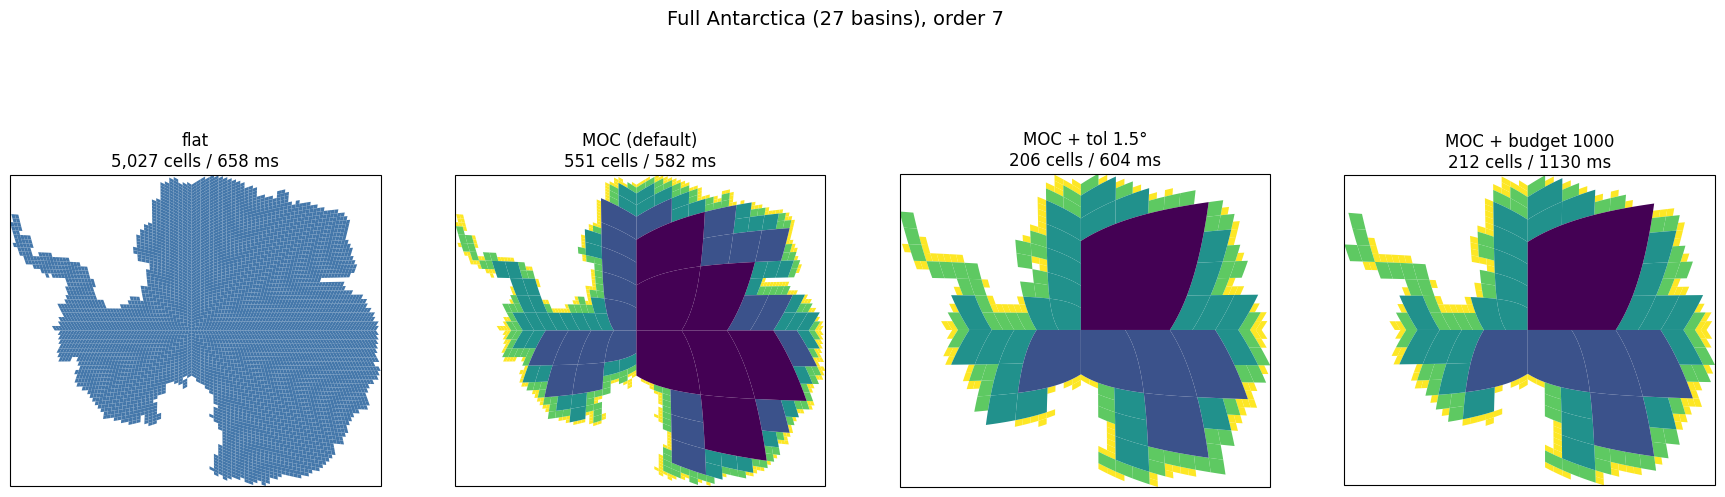

In [7]:
basin_ids = np.unique(data[:, 2]).astype(int)
lats_parts = [data[data[:, 2] == bid, 0] for bid in basin_ids]
lons_parts = [data[data[:, 2] == bid, 1] for bid in basin_ids]
order = 7

def timed(fn):
    t0 = time.perf_counter(); out = fn(); return out, (time.perf_counter() - t0) * 1000

panels = [
    ("flat", *timed(lambda: mortie.morton_coverage(lats_parts, lons_parts, order=order)), False),
    ("MOC (default)", *timed(lambda: mortie.morton_coverage_moc(lats_parts, lons_parts, order=order)), True),
    ("MOC + tol 1.5\u00b0", *timed(lambda: mortie.morton_coverage_moc(lats_parts, lons_parts, order=order, tolerance=1.5)), True),
    ("MOC + budget 1000", *timed(lambda: mortie.morton_coverage_moc(lats_parts, lons_parts, order=order, max_cells=1000)), True),
]
proj = ccrs.SouthPolarStereo()
fig, axes = plt.subplots(1, 4, figsize=(22, 6), subplot_kw=dict(projection=proj))
for ax, (title, cov, ms, byo) in zip(axes, panels):
    draw_cells(ax, cov, order, by_order=byo)
    ax.set_title(f"{title}\n{len(cov):,} cells / {ms:.0f} ms")
plt.suptitle("Full Antarctica (27 basins), order 7", y=1.03, fontsize=14)
plt.show()


## Performance Summary

Timing across polygon types and orders. The hierarchical descent's cost scales with
the **boundary** (cells the polygon edge passes through), not the interior area or
the vertex count — interior regions are captured as a few coarse cells.

In [8]:
results = []

polys = [
    ('Triangle', np.array([40.0,50.0,45.0]), np.array([-120.0,-120.0,-110.0])),
    ('Square', np.array([40.0,40.0,50.0,50.0]), np.array([-125.0,-115.0,-115.0,-125.0])),
]
n = 100
angles = np.linspace(0, 2*np.pi, n, endpoint=False)
polys.append(('Circle100', -75.0 + 5.0*np.cos(angles), 0.0 + 5.0*np.sin(angles)))

for name, la, lo in polys:
    for order in [4, 6, 8]:
        times = []
        for _ in range(5):
            t0 = time.perf_counter()
            cells = mortie.morton_coverage(la, lo, order=order)
            times.append((time.perf_counter()-t0)*1000)
        results.append((name, len(la), order, np.median(times), len(cells)))

for bid in [24, 1, 2]:
    mask = data[:, 2] == bid
    lats = data[mask, 0]; lons = data[mask, 1]
    for order in [4, 6]:
        t0 = time.perf_counter()
        cells = mortie.morton_coverage(lats, lons, order=order)
        dt = (time.perf_counter()-t0)*1000
        results.append((f'Basin {bid}', len(lats), order, dt, len(cells)))

print(f'{"Polygon":<15} {"Verts":>8} {"Order":>6} {"Time (ms)":>10} {"Cells":>8}')
print('-' * 52)
for name, verts, order, ms, ncells in results:
    print(f'{name:<15} {verts:>8} {order:>6} {ms:>10.1f} {ncells:>8}')

Polygon            Verts  Order  Time (ms)    Cells
----------------------------------------------------
Triangle               3      4        0.1        8
Triangle               3      6        0.3       61
Triangle               3      8        0.5      746
Square                 4      4        0.1       12
Square                 4      6        0.2      113
Square                 4      8        0.4     1443
Circle100            100      4        0.1        8
Circle100            100      6        0.2       46
Circle100            100      8        0.3      446
Basin 24           21965      4        5.9        5
Basin 24           21965      6        6.5       24
Basin 1            81595      4       31.1       11
Basin 1            81595      6       39.4       77
Basin 2            43096      4        9.3       12
Basin 2            43096      6       18.5      106


## Holes (donuts) and multipart

Pass a **list of rings** for multipart polygons or holes (even-odd fill). A donut
is `[outer, hole]` — the nested ring carves the hole out. Compare the outer ring
alone (hole-unaware) with the native `[outer, hole]` cover.

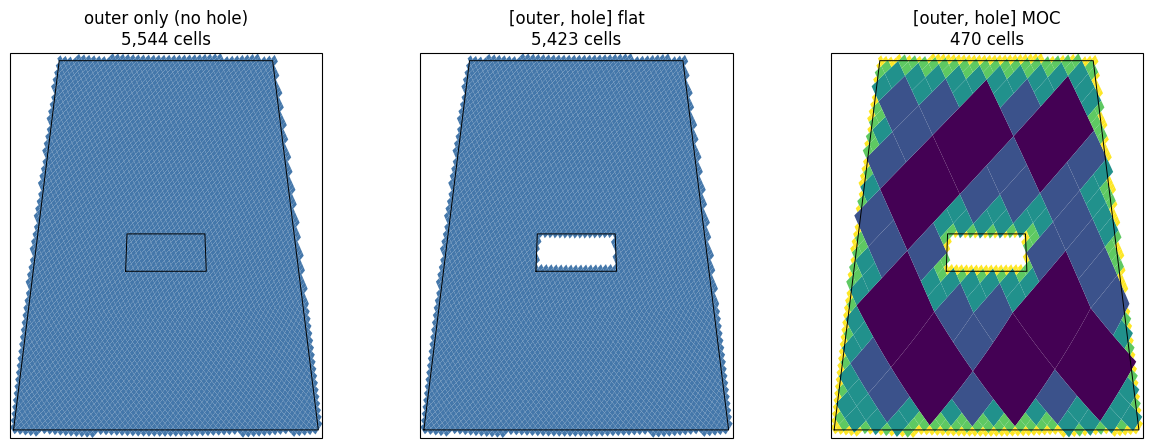

In [9]:
outer = (np.array([35.0, 35.0, 55.0, 55.0]), np.array([-130.0, -110.0, -110.0, -130.0]))
hole = (np.array([44.0, 44.0, 46.0, 46.0]), np.array([-123.0, -117.0, -117.0, -123.0]))
order = 8
proj = ccrs.Orthographic(-120, 45)
panels = [
    ("outer only (no hole)", mortie.morton_coverage(outer[0], outer[1], order=order), False),
    ("[outer, hole] flat", mortie.morton_coverage([outer[0], hole[0]], [outer[1], hole[1]], order=order), False),
    ("[outer, hole] MOC", mortie.morton_coverage_moc([outer[0], hole[0]], [outer[1], hole[1]], order=order), True),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw=dict(projection=proj))
for ax, (title, cov, byo) in zip(axes, panels):
    draw_cells(ax, cov, order, by_order=byo)
    for la, lo in (outer, hole):
        ax.plot(np.append(lo, lo[0]), np.append(la, la[0]), transform=ccrs.PlateCarree(), color="k", lw=0.7)
    ax.set_title(f"{title}\n{len(cov):,} cells")
plt.show()
